In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X=6*np.random.rand(100,1)-3
y=0.5*X**2 + 1.5*X +2 +np.random.randn(100,1)

Text(0, 0.5, 'Y dataset')

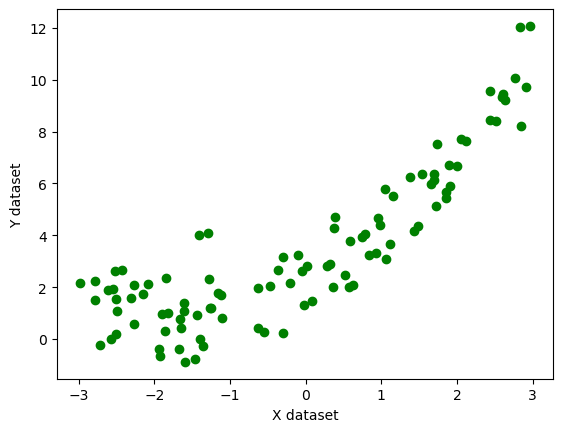

In [3]:
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [5]:
## SLR
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [6]:
regression.fit(X_train,y_train)

LinearRegression()

In [7]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression.predict(X_test))
print(score)

0.8291421269868081


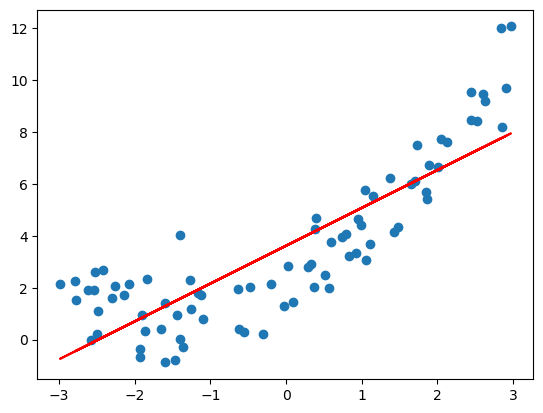

In [8]:
plt.plot(X_train,regression.predict(X_train),color='r')
plt.scatter(X_train,y_train)

In [9]:
# polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [10]:
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [11]:
X_train_poly

array([[ 1.00000000e+00, -1.92701637e+00,  3.71339208e+00],
       [ 1.00000000e+00, -4.73403722e-01,  2.24111084e-01],
       [ 1.00000000e+00, -2.05335012e-01,  4.21624673e-02],
       [ 1.00000000e+00,  2.90866609e+00,  8.46033840e+00],
       [ 1.00000000e+00, -2.48873149e+00,  6.19378442e+00],
       [ 1.00000000e+00,  7.87473171e-01,  6.20113995e-01],
       [ 1.00000000e+00,  2.38650161e-02,  5.69538994e-04],
       [ 1.00000000e+00,  9.23528997e-01,  8.52905808e-01],
       [ 1.00000000e+00,  5.72209934e-01,  3.27424208e-01],
       [ 1.00000000e+00, -2.14630106e+00,  4.60660825e+00],
       [ 1.00000000e+00,  2.63175494e+00,  6.92613407e+00],
       [ 1.00000000e+00,  2.83753310e+00,  8.05159407e+00],
       [ 1.00000000e+00,  9.84838334e-01,  9.69906544e-01],
       [ 1.00000000e+00,  1.42981783e+00,  2.04437903e+00],
       [ 1.00000000e+00, -1.39949506e+00,  1.95858643e+00],
       [ 1.00000000e+00, -1.43812141e+00,  2.06819319e+00],
       [ 1.00000000e+00,  1.85229151e+00

In [12]:
regression.fit(X_train_poly,y_train)
y_pred=regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8579121219685292


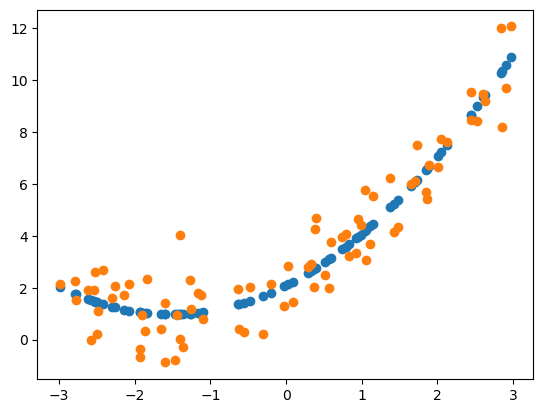

In [13]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [14]:
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [15]:
regression3=LinearRegression()
regression3.fit(X_train_poly,y_train)
y_pred=regression3.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8522830788069041


In [16]:
#Prediction of new data
X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)

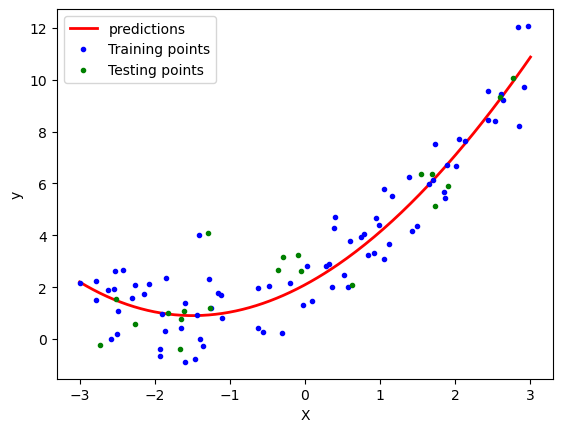

In [17]:
y_new=regression3.predict(X_new_poly)
plt.plot(X_new,y_new,'r-',linewidth=2,label="predictions")
plt.plot(X_train,y_train,'b.',label='Training points')
plt.plot(X_test,y_test,'g.',label='Testing points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# Pipeline Concepts

In [18]:
from sklearn.pipeline import Pipeline

In [19]:
def poly_regression(degree):
    X_new=np.linspace(-3,3,200).reshape(200,1)
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ('lin_reg',lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## polynomial and fit of linear regression on model
    y_pred_new=poly_regression.predict(X_new)

    plt.plot(X_new,y_pred_new,'r',label='Degree'+str(degree))
    plt.plot(X_train,y_train,'b.',linewidth=3)
    plt.plot(X_test,y_test,'g.',linewidth=3)
    plt.legend(loc='upper left')
    plt.xlabel("X")
    plt.ylabel('y')
    plt.axis([-4,4,0,10])
    plt.show()

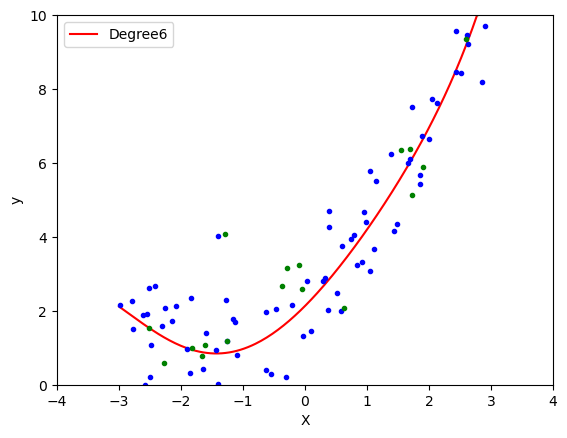

In [24]:
poly_regression(6)